In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)

if gpus:
    print("✅ GPU is ACTIVE — you are ready!")
else:
    print("❌ No GPU — go back and set runtime to T4 GPU")

TensorFlow version: 2.19.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU is ACTIVE — you are ready!


In [10]:
from google.colab import files
uploaded = files.upload()
print("✅ Upload complete!")

Saving archive (1).zip to archive (1) (1).zip
✅ Upload complete!


In [11]:
import zipfile
import os

# Find the zip file name
zip_name = list(uploaded.keys())[0]
print("Zip file:", zip_name)

# Unzip
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/Data')

print("✅ Unzipped successfully!")

# Check what's inside
for item in os.listdir('/content/Data'):
    print("→", item)

Zip file: archive (1) (1).zip
✅ Unzipped successfully!
→ Data


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
import numpy as np
import matplotlib.pyplot as plt
print("✅ All imports successful")

✅ All imports successful


In [13]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,213,316 (100.00 MB)

 Trainable params: 26,212,356 (99.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
import os

data_dir = '/content/Data'

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        print(f"\n📁 {folder}/")
        for subfolder in os.listdir(folder_path):
            sub_path = os.path.join(folder_path, subfolder)
            count = len(os.listdir(sub_path))
            print(f"   └── {subfolder}: {count} images")


📁 Data/
   └── train: 4 images
   └── valid: 4 images
   └── test: 4 images


In [16]:
import os

# Check what's in /content/Data
print("Contents of /content/Data:")
for item in os.listdir('/content/Data'):
    print("→", item)

Contents of /content/Data:
→ Data


In [17]:
# Search for image folders
for root, dirs, files in os.walk('/content/Data'):
    if files:  # only show folders that have files
        print(f"{root}: {len(files)} files")

/content/Data/Data/train/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 files
/content/Data/Data/train/normal: 148 files
/content/Data/Data/train/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 files
/content/Data/Data/train/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 files
/content/Data/Data/valid/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 23 files
/content/Data/Data/valid/normal: 13 files
/content/Data/Data/valid/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 21 files
/content/Data/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 15 files
/content/Data/Data/test/normal: 54 files
/content/Data/Data/test/squamous.cell.carcinoma: 90 files
/content/Data/Data/test/large.cell.carcinoma: 51 files
/content/Data/Data/test/adenocarcinoma: 120 files


Classes found: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Total classes: 4


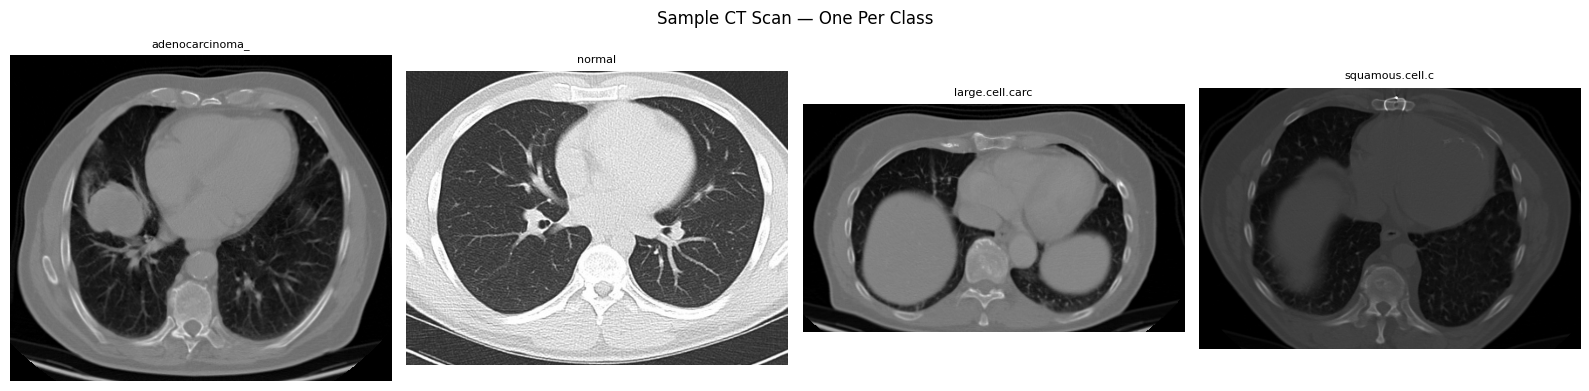

✅ Images displayed!


In [18]:
import os
import cv2
import matplotlib.pyplot as plt

train_dir = '/content/Data/Data/train'
valid_dir = '/content/Data/Data/valid'
test_dir  = '/content/Data/Data/test'

classes = os.listdir(train_dir)
print("Classes found:", classes)
print("Total classes:", len(classes))

# Display one image from each class
fig, axes = plt.subplots(1, len(classes), figsize=(16, 4))

for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls[:15], fontsize=8)  # shortened title
    axes[i].axis('off')

plt.suptitle("Sample CT Scan — One Per Class", fontsize=12)
plt.tight_layout()
plt.show()
print("✅ Images displayed!")

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("\n✅ Data loaded!")
print("Classes:", train_data.class_indices)
print("Training batches:", len(train_data))
print("Validation batches:", len(val_data))

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.

✅ Data loaded!
Classes: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}
Training batches: 20
Validation batches: 3


In [20]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_model.h5',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Best accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.3496 - loss: 3.1099
Epoch 1: val_accuracy improved from None to 0.20833, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.4290 - loss: 3.0120 - val_accuracy: 0.2083 - val_loss: 2.5337 - learning_rate: 1.0000e-04
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.5196 - loss: 2.7549
Epoch 2: val_accuracy did not improve from 0.20833
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.4959 - loss: 2.5045 - val_accuracy: 0.2083 - val_loss: 5.0977 - learning_rate: 1.0000e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.5563 - loss: 1.9306
Epoch 3: val_accuracy did not improve from 0.20833
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 563ms/step - accuracy: 0.5285 - loss: 2.0190 - val_accuracy: 0.2083 - val_loss: 7.6915 - learning_rate: 1.0000e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.4982 - loss: 1.6605
Epoch 4: val_accuracy did not improve from 0.20833

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
20/20 ━━━━━━━━━━━━━

In [21]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Correct paths
train_dir = '/content/Data/Data/train'
valid_dir = '/content/Data/Data/valid'

# Data loaders
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_data.class_indices)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Classes: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}


In [22]:
# Load EfficientNetB0 pretrained on ImageNet
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze base

# Add custom head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model_tl = Model(inputs, outputs)

model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Transfer learning model ready!")
model_tl.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Transfer learning model ready!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [23]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_tl_model.h5',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("🚀 Starting Transfer Learning training...")
history_tl = model_tl.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Best accuracy: {max(history_tl.history['val_accuracy'])*100:.2f}%")

🚀 Starting Transfer Learning training...
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.3091 - loss: 1.6719
Epoch 1: val_accuracy improved from None to 0.20833, saving model to /content/best_tl_model.h5



Epoch 1: finished saving model to /content/best_tl_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.2985 - loss: 1.7815 - val_accuracy: 0.2083 - val_loss: 1.3826 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.2455 - loss: 1.8429
Epoch 2: val_accuracy did not improve from 0.20833
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - accuracy: 0.2594 - loss: 1.7926 - val_accuracy: 0.2083 - val_loss: 1.3845 - learning_rate: 0.0010
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.3146 - loss: 1.6423
Epoch 3: val_accuracy improved from 0.20833 to 0.31944, saving model to /content/best_tl_model.h5



Epoch 3: finished saving model to /content/best_tl_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - accuracy: 0.2659 - loss: 1.6632 - val_accuracy: 0.3194 - val_loss: 1.4042 - learning_rate: 0.0010
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.3078 - loss: 1.5541
Epoch 4: val_accuracy did not improve from 0.31944

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 279ms/step - accuracy: 0.2773 - loss: 1.5642 - val_accuracy: 0.1806 - val_loss: 1.3904 - learning_rate: 0.0010
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.2504 - loss: 1.4816
Epoch 5: val_accuracy improved from 0.31944 to 0.36111, saving model to /content/best_tl_model.h5



Epoch 5: finished saving model to /content/best_tl_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.2936 - loss: 1.4652 - val_accuracy: 0.3611 - val_loss: 1.3849 - learning_rate: 5.0000e-04
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.2540 - loss: 1.5091
Epoch 6: val_accuracy did not improve from 0.36111
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.2741 - loss: 1.4861 - val_accuracy: 0.3194 - val_loss: 1.3787 - learning_rate: 5.0000e-04
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.3448 - loss: 1.4288
Epoch 7: val_accuracy did not improve from 0.36111
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 282ms/step - accuracy: 0.3246 - loss: 1.4282 - val_accuracy: 0.3472 - val_loss: 1.3805 - learning_rate: 5.0000e-04
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.3149 - loss: 1.4167
Epoch 8: val_accuracy did not improve from 0.36111
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 284ms/step - accuracy: 0.3328 - loss: 1.4111 - val_accuracy


Epoch 10: finished saving model to /content/best_tl_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.3230 - loss: 1.3938 - val_accuracy: 0.4722 - val_loss: 1.3813 - learning_rate: 2.5000e-04
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.3410 - loss: 1.3817
Epoch 11: val_accuracy did not improve from 0.47222
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.3181 - loss: 1.3728 - val_accuracy: 0.4444 - val_loss: 1.3737 - learning_rate: 2.5000e-04
Epoch 12/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.3530 - loss: 1.3617
Epoch 12: val_accuracy did not improve from 0.47222
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.3328 - loss: 1.3759 - val_accuracy: 0.4583 - val_loss: 1.3739 - learning_rate: 2.5000e-04
Epoch 13/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.3270 - loss: 1.3672
Epoch 13: val_accuracy did not improve from 0.47222
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.3328 - loss: 1.3652 - val_ac

In [24]:
import os

train_dir = '/content/Data/Data/train'
valid_dir = '/content/Data/Data/valid'
test_dir = '/content/Data/Data/test'

print("TRAIN classes:")
for c in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, c)))
    print(f"  {c}: {count} images")

print("\nVALID classes:")
for c in os.listdir(valid_dir):
    count = len(os.listdir(os.path.join(valid_dir, c)))
    print(f"  {c}: {count} images")

print("\nTEST classes:")
for c in os.listdir(test_dir):
    count = len(os.listdir(os.path.join(test_dir, c)))
    print(f"  {c}: {count} images")

TRAIN classes:
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 images
  normal: 148 images
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 images
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 images

VALID classes:
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 23 images
  normal: 13 images
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 21 images
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 15 images

TEST classes:
  normal: 54 images
  squamous.cell.carcinoma: 90 images
  large.cell.carcinoma: 51 images
  adenocarcinoma: 120 images


In [25]:
import shutil, os

# Create clean organized folders
base = '/content/CleanData'
classes_map = {
    'adenocarcinoma': [],
    'large_cell_carcinoma': [],
    'squamous_cell_carcinoma': [],
    'normal': []
}

# Create clean folders
for cls in classes_map:
    os.makedirs(f'{base}/train/{cls}', exist_ok=True)
    os.makedirs(f'{base}/valid/{cls}', exist_ok=True)

print("✅ Clean folders created")
print(os.listdir(f'{base}/train'))

✅ Clean folders created
['large_cell_carcinoma', 'normal', 'squamous_cell_carcinoma', 'adenocarcinoma']


In [26]:
import shutil
import os

train_dir = '/content/Data/Data/train'
valid_dir = '/content/Data/Data/valid'
test_dir  = '/content/Data/Data/test'
base      = '/content/CleanData'

# Mapping: keyword to clean class name
def get_class(folder_name):
    folder_name = folder_name.lower()
    if 'normal' in folder_name:
        return 'normal'
    elif 'adenocarcinoma' in folder_name:
        return 'adenocarcinoma'
    elif 'large' in folder_name:
        return 'large_cell_carcinoma'
    elif 'squamous' in folder_name:
        return 'squamous_cell_carcinoma'
    return None

# Copy train images
print("Copying train images...")
for folder in os.listdir(train_dir):
    cls = get_class(folder)
    if cls is None:
        continue
    src_folder = os.path.join(train_dir, folder)
    dst_folder = os.path.join(base, 'train', cls)
    os.makedirs(dst_folder, exist_ok=True)
    for img in os.listdir(src_folder):
        shutil.copy(
            os.path.join(src_folder, img),
            os.path.join(dst_folder, img)
        )

# Copy valid images
print("Copying valid images...")
for folder in os.listdir(valid_dir):
    cls = get_class(folder)
    if cls is None:
        continue
    src_folder = os.path.join(valid_dir, folder)
    dst_folder = os.path.join(base, 'valid', cls)
    os.makedirs(dst_folder, exist_ok=True)
    for img in os.listdir(src_folder):
        shutil.copy(
            os.path.join(src_folder, img),
            os.path.join(dst_folder, img)
        )

# Verify
print("\n✅ Done! Clean dataset summary:")
for split in ['train', 'valid']:
    print(f"\n{split}/")
    for cls in os.listdir(os.path.join(base, split)):
        count = len(os.listdir(os.path.join(base, split, cls)))
        print(f"   {cls}: {count} images")

Copying train images...
Copying valid images...

✅ Done! Clean dataset summary:

train/
   large_cell_carcinoma: 115 images
   normal: 148 images
   squamous_cell_carcinoma: 155 images
   adenocarcinoma: 195 images

valid/
   large_cell_carcinoma: 21 images
   normal: 13 images
   squamous_cell_carcinoma: 15 images
   adenocarcinoma: 23 images


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf

clean_train = '/content/CleanData/train'
clean_valid = '/content/CleanData/valid'

# Data loaders
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    clean_train,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    clean_valid,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

print("✅ Classes:", train_data.class_indices)
print("Training images:", train_data.samples)
print("Validation images:", val_data.samples)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
✅ Classes: {'adenocarcinoma': 0, 'large_cell_carcinoma': 1, 'normal': 2, 'squamous_cell_carcinoma': 3}
Training images: 613
Validation images: 72


In [28]:
# Build model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model_tl = Model(inputs, outputs)
model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_clean_model.h5',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("🚀 Training started...")
history = model_tl.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Best accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

🚀 Training started...
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.2805 - loss: 1.7346
Epoch 1: val_accuracy improved from None to 0.31944, saving model to /content/best_clean_model.h5



Epoch 1: finished saving model to /content/best_clean_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 59s 960ms/step - accuracy: 0.2708 - loss: 1.7832 - val_accuracy: 0.3194 - val_loss: 1.3884 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2730 - loss: 1.7806
Epoch 2: val_accuracy did not improve from 0.31944
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.2855 - loss: 1.6782 - val_accuracy: 0.3194 - val_loss: 1.3853 - learning_rate: 0.0010
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.2663 - loss: 1.5755
Epoch 3: val_accuracy did not improve from 0.31944
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.2887 - loss: 1.5877 - val_accuracy: 0.3194 - val_loss: 1.3804 - learning_rate: 0.0010
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.2667 - loss: 1.5668
Epoch 4: val_accuracy did not improve from 0.31944
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step - accuracy: 0.2790 - loss: 1.5742 - val_accuracy: 0.1806 


Epoch 5: finished saving model to /content/best_clean_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 298ms/step - accuracy: 0.3034 - loss: 1.4740 - val_accuracy: 0.3472 - val_loss: 1.3845 - learning_rate: 0.0010
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.2721 - loss: 1.4813
Epoch 6: val_accuracy did not improve from 0.34722

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 274ms/step - accuracy: 0.3002 - loss: 1.4535 - val_accuracy: 0.2361 - val_loss: 1.3839 - learning_rate: 0.0010
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.2709 - loss: 1.4377
Epoch 7: val_accuracy improved from 0.34722 to 0.37500, saving model to /content/best_clean_model.h5



Epoch 7: finished saving model to /content/best_clean_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - accuracy: 0.3083 - loss: 1.4301 - val_accuracy: 0.3750 - val_loss: 1.3833 - learning_rate: 5.0000e-04
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.2898 - loss: 1.3948
Epoch 8: val_accuracy improved from 0.37500 to 0.45833, saving model to /content/best_clean_model.h5



Epoch 8: finished saving model to /content/best_clean_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - accuracy: 0.3181 - loss: 1.4075 - val_accuracy: 0.4583 - val_loss: 1.3824 - learning_rate: 5.0000e-04
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.3388 - loss: 1.3659
Epoch 9: val_accuracy did not improve from 0.45833
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 290ms/step - accuracy: 0.3426 - loss: 1.3771 - val_accuracy: 0.4583 - val_loss: 1.3802 - learning_rate: 5.0000e-04
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.3325 - loss: 1.3865
Epoch 10: val_accuracy did not improve from 0.45833
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.3426 - loss: 1.3658 - val_accuracy: 0.3333 - val_loss: 1.3785 - learning_rate: 5.0000e-04
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.2930 - loss: 1.3911
Epoch 11: val_accuracy did not improve from 0.45833
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.3214 - loss: 1.3622 - val_a

In [30]:
import shutil, os

src_dirs = [
    '/content/Data/Data/train',
    '/content/Data/Data/valid',
    '/content/Data/Data/test'
]

base = '/content/AllData'

def get_class(folder_name):
    folder_name = folder_name.lower()
    if 'normal' in folder_name:
        return 'normal'
    elif 'adenocarcinoma' in folder_name:
        return 'adenocarcinoma'
    elif 'large' in folder_name:
        return 'large_cell_carcinoma'
    elif 'squamous' in folder_name:
        return 'squamous_cell_carcinoma'
    return None

# Copy ALL images from train + valid + test into one folder
count = 0
for src_dir in src_dirs:
    for folder in os.listdir(src_dir):
        cls = get_class(folder)
        if cls is None:
            continue
        dst = os.path.join(base, cls)
        os.makedirs(dst, exist_ok=True)
        src_folder = os.path.join(src_dir, folder)
        for img in os.listdir(src_folder):
            dst_path = os.path.join(dst, f"{count}_{img}")
            shutil.copy(os.path.join(src_folder, img), dst_path)
            count += 1

print("✅ All images combined!")
for cls in os.listdir(base):
    print(f"  {cls}: {len(os.listdir(os.path.join(base, cls)))} images")

✅ All images combined!
  large_cell_carcinoma: 187 images
  normal: 215 images
  squamous_cell_carcinoma: 260 images
  adenocarcinoma: 338 images


In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf

data_dir = '/content/AllData'

# Single datagen with validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2      # 80% train 20% val
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("✅ Data ready!")
print("Classes:", train_data.class_indices)
print("Training images:", train_data.samples)
print("Validation images:", val_data.samples)

Found 801 images belonging to 4 classes.
Found 199 images belonging to 4 classes.
✅ Data ready!
Classes: {'adenocarcinoma': 0, 'large_cell_carcinoma': 1, 'normal': 2, 'squamous_cell_carcinoma': 3}
Training images: 801
Validation images: 199


In [33]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = '/content/AllData'

# Data loaders
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("✅ Data loaded!")
print("Training images:", train_data.samples)
print("Validation images:", val_data.samples)

Found 801 images belonging to 4 classes.
Found 199 images belonging to 4 classes.
✅ Data loaded!
Training images: 801
Validation images: 199


In [34]:
# Load VGG16 pretrained
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all base layers
base_model.trainable = False

# Build model
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model_vgg = Model(inputs, outputs)

model_vgg.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ VGG16 model ready!")
model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ VGG16 model ready!


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,692,612 (105.64 MB)

 Trainable params: 12,977,924 (49.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [35]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_vgg_model.h5',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, verbose=1)
]

print("🚀 Training VGG16...")
history_vgg = model_vgg.fit(
    train_data,
    epochs=50,
    validation_data=val_data,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Best val accuracy: {max(history_vgg.history['val_accuracy'])*100:.2f}%")

🚀 Training VGG16...
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.3549 - loss: 1.4790
Epoch 1: val_accuracy improved from None to 0.51256, saving model to /content/best_vgg_model.h5



Epoch 1: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3708 - loss: 1.4007 - val_accuracy: 0.5126 - val_loss: 1.0524 - learning_rate: 1.0000e-04
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.5419 - loss: 1.1081
Epoch 2: val_accuracy improved from 0.51256 to 0.65829, saving model to /content/best_vgg_model.h5



Epoch 2: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 726ms/step - accuracy: 0.5119 - loss: 1.1065 - val_accuracy: 0.6583 - val_loss: 0.9010 - learning_rate: 1.0000e-04
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.5615 - loss: 0.9871
Epoch 3: val_accuracy did not improve from 0.65829
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 693ms/step - accuracy: 0.5643 - loss: 0.9822 - val_accuracy: 0.6281 - val_loss: 0.9413 - learning_rate: 1.0000e-04
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.5952 - loss: 0.9548
Epoch 4: val_accuracy did not improve from 0.65829
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 746ms/step - accuracy: 0.5705 - loss: 0.9685 - val_accuracy: 0.6080 - val_loss: 0.8756 - learning_rate: 1.0000e-04
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.6068 - loss: 0.8889
Epoch 5: val_accuracy improved from 0.65829 to 0.67839, saving model to /content/best_vgg_model.h5



Epoch 5: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 712ms/step - accuracy: 0.5730 - loss: 0.9472 - val_accuracy: 0.6784 - val_loss: 0.8041 - learning_rate: 1.0000e-04
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.6326 - loss: 0.9132
Epoch 6: val_accuracy did not improve from 0.67839
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 718ms/step - accuracy: 0.6180 - loss: 0.8864 - val_accuracy: 0.6533 - val_loss: 0.7798 - learning_rate: 1.0000e-04
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.5816 - loss: 0.8745
Epoch 7: val_accuracy did not improve from 0.67839
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 694ms/step - accuracy: 0.6180 - loss: 0.8480 - val_accuracy: 0.6683 - val_loss: 0.8066 - learning_rate: 1.0000e-04
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.6191 - loss: 0.8610
Epoch 8: val_accuracy did not improve from 0.67839
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 712ms/step - accuracy: 0.6342 - loss: 0.8412 - val_accurac


Epoch 9: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 709ms/step - accuracy: 0.6380 - loss: 0.7951 - val_accuracy: 0.7387 - val_loss: 0.6711 - learning_rate: 1.0000e-04
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.6484 - loss: 0.7800
Epoch 10: val_accuracy did not improve from 0.73869
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 690ms/step - accuracy: 0.6504 - loss: 0.7847 - val_accuracy: 0.6985 - val_loss: 0.7262 - learning_rate: 1.0000e-04
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6295 - loss: 0.8012
Epoch 11: val_accuracy improved from 0.73869 to 0.74874, saving model to /content/best_vgg_model.h5


...


Epoch 20: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 702ms/step - accuracy: 0.7703 - loss: 0.5619 - val_accuracy: 0.8442 - val_loss: 0.4892 - learning_rate: 1.0000e-04
Epoch 21/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.7437 - loss: 0.5747
Epoch 21: val_accuracy did not improve from 0.84422
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 753ms/step - accuracy: 0.7690 - loss: 0.5505 - val_accuracy: 0.8090 - val_loss: 0.4969 - learning_rate: 1.0000e-04
Epoch 22/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.8024 - loss: 0.5306
Epoch 22: val_accuracy did not improve from 0.84422
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 682ms/step - accuracy: 0.7778 - loss: 0.5450 - val_accuracy: 0.8442 - val_loss: 0.4793 - learning_rate: 1.0000e-04
Epoch 23/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.7632 - loss: 0.5512
Epoch 23: val_accuracy improved from 0.84422 to 0.88442, saving model to /content/best_vgg_model.h5



Epoch 23: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 701ms/step - accuracy: 0.7728 - loss: 0.5379 - val_accuracy: 0.8844 - val_loss: 0.4344 - learning_rate: 1.0000e-04
Epoch 24/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.8080 - loss: 0.4960
Epoch 24: val_accuracy did not improve from 0.88442
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 676ms/step - accuracy: 0.8040 - loss: 0.5038 - val_accuracy: 0.7990 - val_loss: 0.4632 - learning_rate: 1.0000e-04
Epoch 25/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.8147 - loss: 0.4641
Epoch 25: val_accuracy did not improve from 0.88442
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 711ms/step - accuracy: 0.8227 - loss: 0.4472 - val_accuracy: 0.8342 - val_loss: 0.4471 - learning_rate: 1.0000e-04
Epoch 26/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.7459 - loss: 0.5598
Epoch 26: val_accuracy did not improve from 0.88442
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 683ms/step - accuracy: 0.7628 - loss: 0.5399 - val_


Epoch 34: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 717ms/step - accuracy: 0.8627 - loss: 0.3491 - val_accuracy: 0.8945 - val_loss: 0.3225 - learning_rate: 1.0000e-04
Epoch 35/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8685 - loss: 0.3261
Epoch 35: val_accuracy did not improve from 0.89447
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 713ms/step - accuracy: 0.8564 - loss: 0.3575 - val_accuracy: 0.8945 - val_loss: 0.3213 - learning_rate: 1.0000e-04
Epoch 36/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9029 - loss: 0.3064
Epoch 36: val_accuracy did not improve from 0.89447
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 731ms/step - accuracy: 0.9014 - loss: 0.3074 - val_accuracy: 0.8894 - val_loss: 0.2656 - learning_rate: 1.0000e-04
Epoch 37/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.8738 - loss: 0.3409
Epoch 37: val_accuracy did not improve from 0.89447
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 683ms/step - accuracy: 0.8564 - loss: 0.3634 - val_


Epoch 38: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 717ms/step - accuracy: 0.8739 - loss: 0.3489 - val_accuracy: 0.9095 - val_loss: 0.3005 - learning_rate: 1.0000e-04
Epoch 39/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.8715 - loss: 0.3527
Epoch 39: val_accuracy improved from 0.90955 to 0.92965, saving model to /content/best_vgg_model.h5



Epoch 39: finished saving model to /content/best_vgg_model.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 766ms/step - accuracy: 0.8864 - loss: 0.3249 - val_accuracy: 0.9296 - val_loss: 0.2679 - learning_rate: 1.0000e-04
Epoch 40/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9137 - loss: 0.3118
Epoch 40: val_accuracy did not improve from 0.92965

Epoch 40: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 684ms/step - accuracy: 0.9001 - loss: 0.3015 - val_accuracy: 0.9045 - val_loss: 0.2992 - learning_rate: 1.0000e-04
Epoch 41/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.8668 - loss: 0.3325
Epoch 41: val_accuracy did not improve from 0.92965
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 689ms/step - accuracy: 0.8876 - loss: 0.3009 - val_accuracy: 0.9246 - val_loss: 0.2534 - learning_rate: 3.0000e-05
Epoch 42/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8931 - loss: 0.3149
Epoch 42: val_accuracy did not improve from 0.92965
26/

In [36]:
from google.colab import drive
drive.mount('/content/drive')

# Save to Google Drive
model_vgg.save('/content/drive/MyDrive/final_model.h5')
print("✅ Model saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to Google Drive!


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 676ms/step


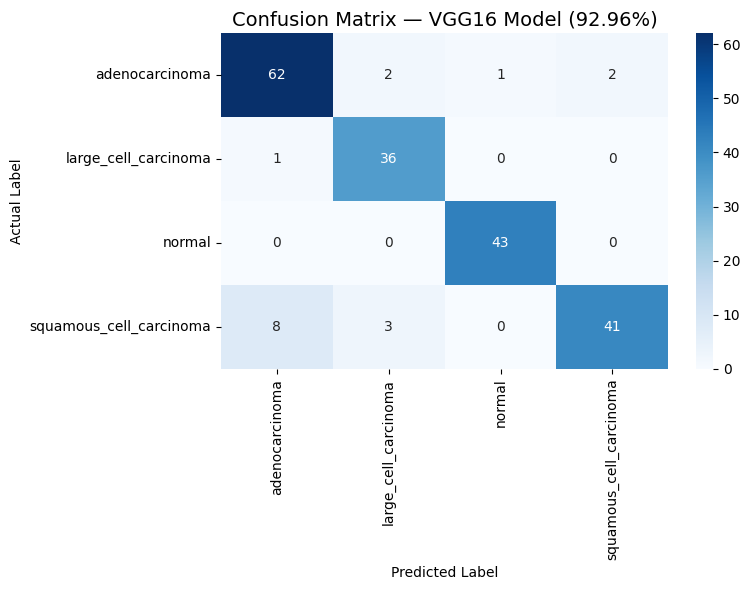

✅ Confusion matrix saved!


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
val_data.reset()
y_pred_probs = model_vgg.predict(val_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — VGG16 Model (92.96%)', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [38]:
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
)
print("Classification Report:")
print("="*60)
print(report)

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma     0.8732    0.9254    0.8986        67
   large_cell_carcinoma     0.8780    0.9730    0.9231        37
                 normal     0.9773    1.0000    0.9885        43
squamous_cell_carcinoma     0.9535    0.7885    0.8632        52

               accuracy                         0.9146       199
              macro avg     0.9205    0.9217    0.9183       199
           weighted avg     0.9176    0.9146    0.9133       199



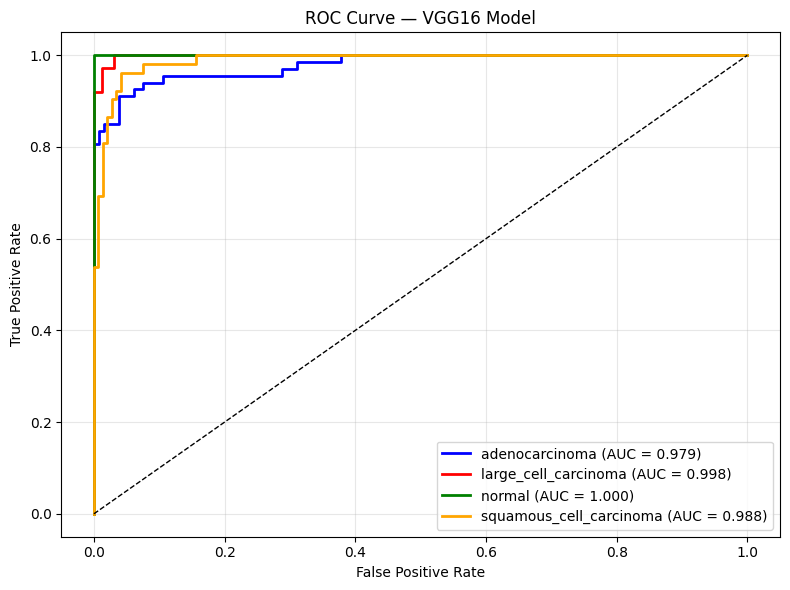

✅ ROC curve saved!


In [39]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=range(4))
colors = ['blue', 'red', 'green', 'orange']

plt.figure(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — VGG16 Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/roc_curve.png', dpi=150)
plt.show()
print("✅ ROC curve saved!")

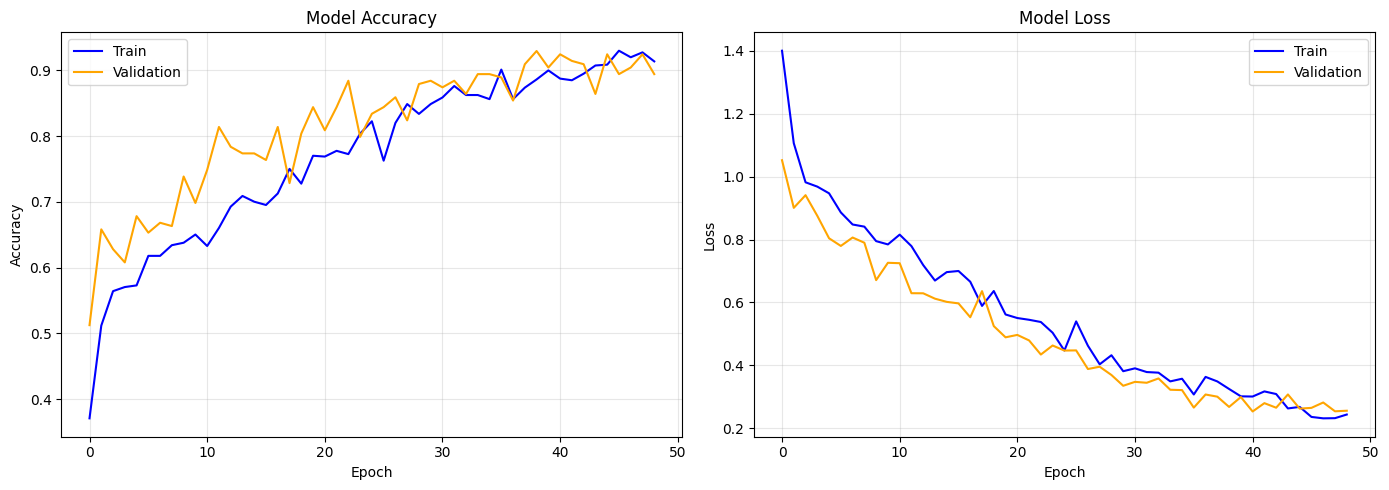

✅ Training history saved!


In [40]:
import matplotlib.pyplot as plt

# Save training history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg.history['accuracy'], label='Train', color='blue')
axes[0].plot(history_vgg.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_vgg.history['loss'], label='Train', color='blue')
axes[1].plot(history_vgg.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png', dpi=150)
plt.show()
print("✅ Training history saved!")

In [41]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

# Copy model to Google Drive
shutil.copy('/content/best_vgg_model.h5',
            '/content/drive/MyDrive/final_model.h5')

print("✅ Model saved to Google Drive!")

# Verify
import os
size = os.path.getsize('/content/drive/MyDrive/final_model.h5')
print(f"File size: {size/1024/1024:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved to Google Drive!
File size: 204.7 MB


In [42]:
import tensorflow as tf

# Load the model from Google Drive
model = tf.keras.models.load_model('/content/drive/MyDrive/final_model.h5')

print("✅ Model loaded successfully!")
model.summary()

✅ Model loaded successfully!


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,692,614 (105.64 MB)

 Trainable params: 12,977,924 (49.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

In [44]:
import os

test_dir = '/content/Data/Data/test'

# Find first image in each class
for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        images = os.listdir(cls_path)
        if images:
            print(f"{cls}: {cls_path}/{images[0]}")

normal: /content/Data/Data/test/normal/8 (2).png
squamous.cell.carcinoma: /content/Data/Data/test/squamous.cell.carcinoma/000124 (4).png
large.cell.carcinoma: /content/Data/Data/test/large.cell.carcinoma/000150.png
adenocarcinoma: /content/Data/Data/test/adenocarcinoma/000137 (4).png


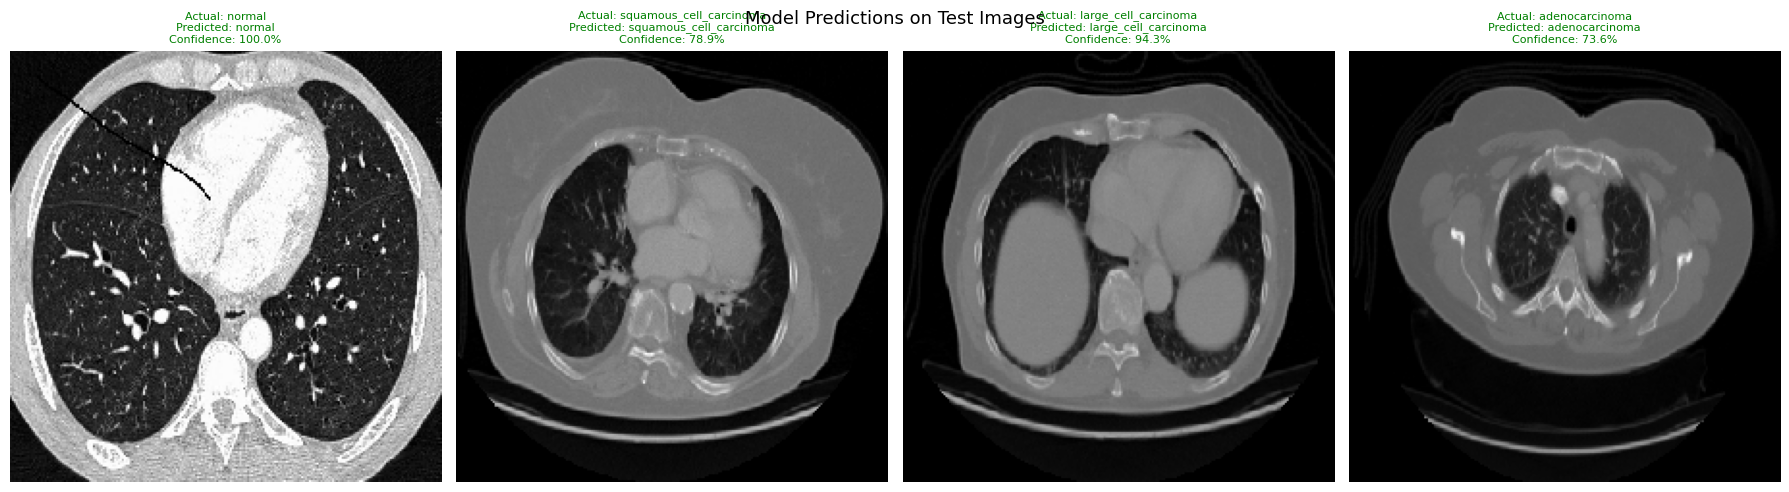

✅ Test predictions saved to Drive!


In [45]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Exact correct paths from your dataset
test_images = {
    'normal': '/content/Data/Data/test/normal/8 (2).png',
    'squamous_cell_carcinoma': '/content/Data/Data/test/squamous.cell.carcinoma/000124 (4).png',
    'large_cell_carcinoma': '/content/Data/Data/test/large.cell.carcinoma/000150.png',
    'adenocarcinoma': '/content/Data/Data/test/adenocarcinoma/000137 (4).png'
}

class_names = ['adenocarcinoma', 'large_cell_carcinoma',
               'normal', 'squamous_cell_carcinoma']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (actual_class, img_path) in enumerate(test_images.items()):
    # Load and preprocess
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Display
    axes[i].imshow(image.load_img(img_path, target_size=(224, 224)))
    axes[i].axis('off')

    # Green if correct, red if wrong
    color = 'green' if predicted_class == actual_class else 'red'
    axes[i].set_title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.1f}%",
        fontsize=8, color=color
    )

plt.suptitle("Model Predictions on Test Images", fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/test_predictions.png', dpi=150)
plt.show()
print("✅ Test predictions saved to Drive!")

In [46]:
import numpy as np
from tensorflow.keras.preprocessing import image

test_images = {
    'normal': '/content/Data/Data/test/normal/8 (2).png',
    'squamous_cell_carcinoma': '/content/Data/Data/test/squamous.cell.carcinoma/000124 (4).png',
    'large_cell_carcinoma': '/content/Data/Data/test/large.cell.carcinoma/000150.png',
    'adenocarcinoma': '/content/Data/Data/test/adenocarcinoma/000137 (4).png'
}

class_names = ['adenocarcinoma', 'large_cell_carcinoma',
               'normal', 'squamous_cell_carcinoma']

print("="*55)
print("      MODEL PREDICTION RESULTS")
print("="*55)

correct = 0
for actual_class, img_path in test_images.items():
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    status = "✅ CORRECT" if predicted_class == actual_class else "❌ WRONG"
    if predicted_class == actual_class:
        correct += 1

    print(f"\nActual:    {actual_class}")
    print(f"Predicted: {predicted_class}")
    print(f"Confidence:{confidence:.2f}%")
    print(f"Result:    {status}")
    print("-"*55)

print(f"\nFinal Score: {correct}/4 correct")

      MODEL PREDICTION RESULTS

Actual:    normal
Predicted: normal
Confidence:99.98%
Result:    ✅ CORRECT
-------------------------------------------------------

Actual:    squamous_cell_carcinoma
Predicted: squamous_cell_carcinoma
Confidence:78.90%
Result:    ✅ CORRECT
-------------------------------------------------------

Actual:    large_cell_carcinoma
Predicted: large_cell_carcinoma
Confidence:94.31%
Result:    ✅ CORRECT
-------------------------------------------------------

Actual:    adenocarcinoma
Predicted: adenocarcinoma
Confidence:73.64%
Result:    ✅ CORRECT
-------------------------------------------------------

Final Score: 4/4 correct
